# Notebook 4: Modeling

Builds predictive models for NBA player salary using the cleaned dataset from Notebook 2.

**Models:**
1. PCA — Dimensionality reduction & player structure visualization
2. K-Means Clustering — Player archetypes
3. Linear Regression — Baseline salary prediction (`LOG_SALARY`)
4. Regularized Regression — Lasso, Ridge, ElasticNet
5. Decision Tree — Salary tier classification with depth tuning
6. Logistic Regression — Salary tier classification (pipeline)
7. Random Forest — Ensemble classification

In [23]:
from pathlib import Path

import polars as pl
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, log_loss,
)

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = PROCESSED_DIR

plt.rcParams["figure.dpi"] = 120

# Load game-level dataset
df = pl.read_parquet(PROCESSED_DIR / "nba_player_games_clean.parquet")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded: 119,227 rows x 54 columns


---
## Section 1: Feature Preparation

Aggregate game-level rows to player-season level, then prepare features for modeling.

In [24]:
# Aggregate game-level -> player-season level
STAT_COLS = [
    "MIN", "PTS", "REB", "AST", "STL", "BLK", "TOV",
    "FGM", "FGA", "FG_PCT", "FG3M", "FG3A", "FG3_PCT", "FTM", "FTA", "FT_PCT",
    "OREB", "DREB", "PLUS_MINUS", "NBA_FANTASY_PTS",
    "PTS_PER36", "REB_PER36", "AST_PER36", "STL_PER36", "BLK_PER36", "TOV_PER36",
    "USAGE_PROXY",
]

agg_exprs = [pl.col(c).mean().alias(c) for c in STAT_COLS]
agg_exprs += [
    pl.col("WIN").mean().alias("WIN_PCT"),
    pl.col("IS_HOME").mean().alias("HOME_PCT"),
    pl.col("SEASON_SALARY").first(),
    pl.col("LOG_SALARY").first(),
    pl.col("SALARY_TIER").first(),
    pl.col("SALARY_TIER_NUM").first(),
    pl.col("POSITION_SIMPLE").first(),
    pl.col("AGE_AT_GAME").mean().alias("AGE"),
    pl.col("HEIGHT").first(),
    pl.col("WEIGHT").first(),
    pl.col("YEARS_EXP").first(),
    pl.col("REDDIT_SENTIMENT_AVG").mean().alias("REDDIT_SENTIMENT"),
    pl.col("REDDIT_POST_COUNT").sum().alias("REDDIT_POSTS"),
    pl.col("GAME_ID").n_unique().alias("GAMES_PLAYED"),
]

player_season = (
    df.group_by(["PLAYER_NAME", "SEASON"])
    .agg(agg_exprs)
    .sort(["PLAYER_NAME", "SEASON"])
)

print(f"Player-season dataset: {player_season.shape[0]:,} rows x {player_season.shape[1]} cols")
print(f"Seasons: {sorted(player_season['SEASON'].unique().to_list())}")

Player-season dataset: 2,427 rows x 43 cols
Seasons: ['2020-21', '2021-22', '2022-23', '2023-24', '2024-25']


In [25]:
# Define feature columns
NUMERIC_FEATURES = [
    "PTS_PER36", "REB_PER36", "AST_PER36", "STL_PER36", "BLK_PER36", "TOV_PER36",
    "FG_PCT", "FG3_PCT", "FT_PCT",
    "USAGE_PROXY", "MIN", "PLUS_MINUS",
    "WIN_PCT", "GAMES_PLAYED",
    "REDDIT_SENTIMENT", "REDDIT_POSTS",
]
BIO_FEATURES = ["AGE", "HEIGHT_INCHES", "WEIGHT"]

# Convert to pandas for sklearn
pdf = player_season.to_pandas()

# Convert HEIGHT "6-6" -> inches (78)
def height_to_inches(h):
    if pd.isna(h) or not isinstance(h, str) or '-' not in str(h):
        return np.nan
    parts = str(h).split('-')
    return int(parts[0]) * 12 + int(parts[1])

pdf["HEIGHT_INCHES"] = pdf["HEIGHT"].apply(height_to_inches)

# Drop rows with critical nulls
pdf_full = pdf.dropna(subset=NUMERIC_FEATURES + BIO_FEATURES).copy()
print(f"Rows after dropping nulls: {len(pdf_full):,} (of {len(pdf):,})")

# One-hot encode position
pos_dummies = pd.get_dummies(pdf_full["POSITION_SIMPLE"], prefix="POS", dtype=float)
pdf_full = pd.concat([pdf_full, pos_dummies], axis=1)

ALL_FEATURES = NUMERIC_FEATURES + BIO_FEATURES + list(pos_dummies.columns)
print(f"Total features: {len(ALL_FEATURES)}")
print(f"Features: {ALL_FEATURES}")

Rows after dropping nulls: 1,765 (of 2,427)
Total features: 24
Features: ['PTS_PER36', 'REB_PER36', 'AST_PER36', 'STL_PER36', 'BLK_PER36', 'TOV_PER36', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'USAGE_PROXY', 'MIN', 'PLUS_MINUS', 'WIN_PCT', 'GAMES_PLAYED', 'REDDIT_SENTIMENT', 'REDDIT_POSTS', 'AGE', 'HEIGHT_INCHES', 'WEIGHT', 'POS_C', 'POS_PF', 'POS_PG', 'POS_SF', 'POS_SG']


In [26]:
# Prepare X and y
X = pdf_full[ALL_FEATURES].values
y_reg = pdf_full["LOG_SALARY"].values      # regression target
y_cls = pdf_full["SALARY_TIER"].values     # classification target

# Train/test split
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
_, _, y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)

# Standardize — fit on train, apply to test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Also scale the full dataset for PCA/KMeans
X_all_scaled = scaler.transform(X)

print(f"Train: {X_train_scaled.shape[0]} samples")
print(f"Test:  {X_test_scaled.shape[0]} samples")

Train: 1412 samples
Test:  353 samples


---
## Section 2: PCA — Player Structure Visualization

Reduce the feature space to 2 principal components and visualize player structure.

In [27]:
# PCA — fit on full scaled data
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_all_scaled)

print("Explained variance ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f}  (cumulative: {sum(pca.explained_variance_ratio_[:i+1]):.4f})")

Explained variance ratio:
  PC1: 0.1818  (cumulative: 0.1818)
  PC2: 0.1513  (cumulative: 0.3331)
  PC3: 0.0832  (cumulative: 0.4163)
  PC4: 0.0771  (cumulative: 0.4934)
  PC5: 0.0641  (cumulative: 0.5575)


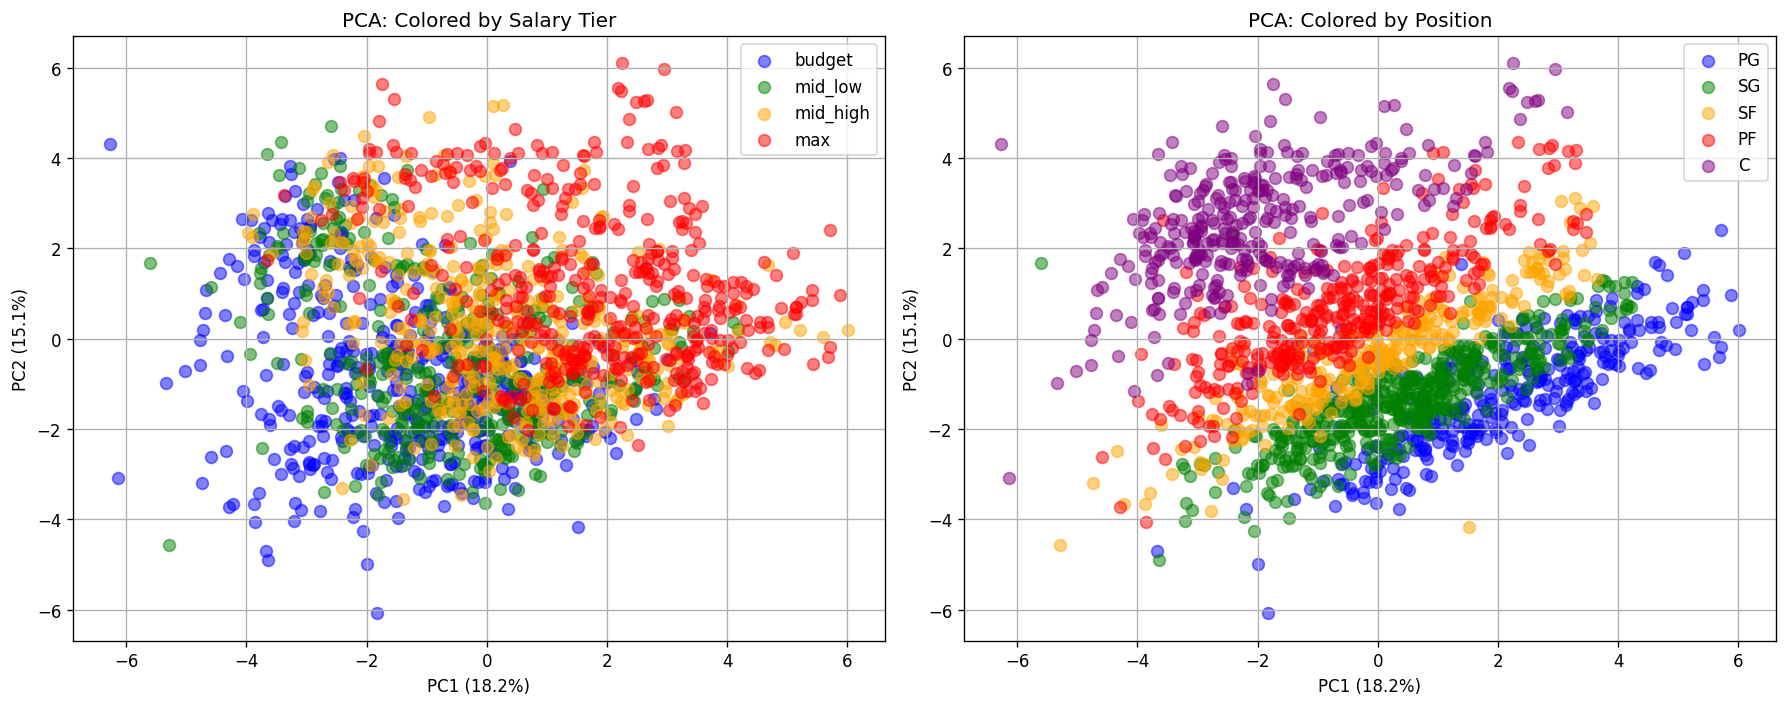

In [28]:
# Scatter plot: PC1 vs PC2, colored by salary tier
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

tier_colors = {"budget": "blue", "mid_low": "green", "mid_high": "orange", "max": "red"}
for tier in ["budget", "mid_low", "mid_high", "max"]:
    mask = pdf_full["SALARY_TIER"].values == tier
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=tier_colors[tier], label=tier, alpha=0.5, s=50, marker='o')
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("PCA: Colored by Salary Tier")
axes[0].legend()
axes[0].grid()

# Colored by position
pos_colors = {"PG": "blue", "SG": "green", "SF": "orange", "PF": "red", "C": "purple"}
for pos in ["PG", "SG", "SF", "PF", "C"]:
    mask = pdf_full["POSITION_SIMPLE"].values == pos
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=pos_colors[pos], label=pos, alpha=0.5, s=50, marker='o')
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("PCA: Colored by Position")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_pca_scatter.png", bbox_inches="tight")
plt.show()

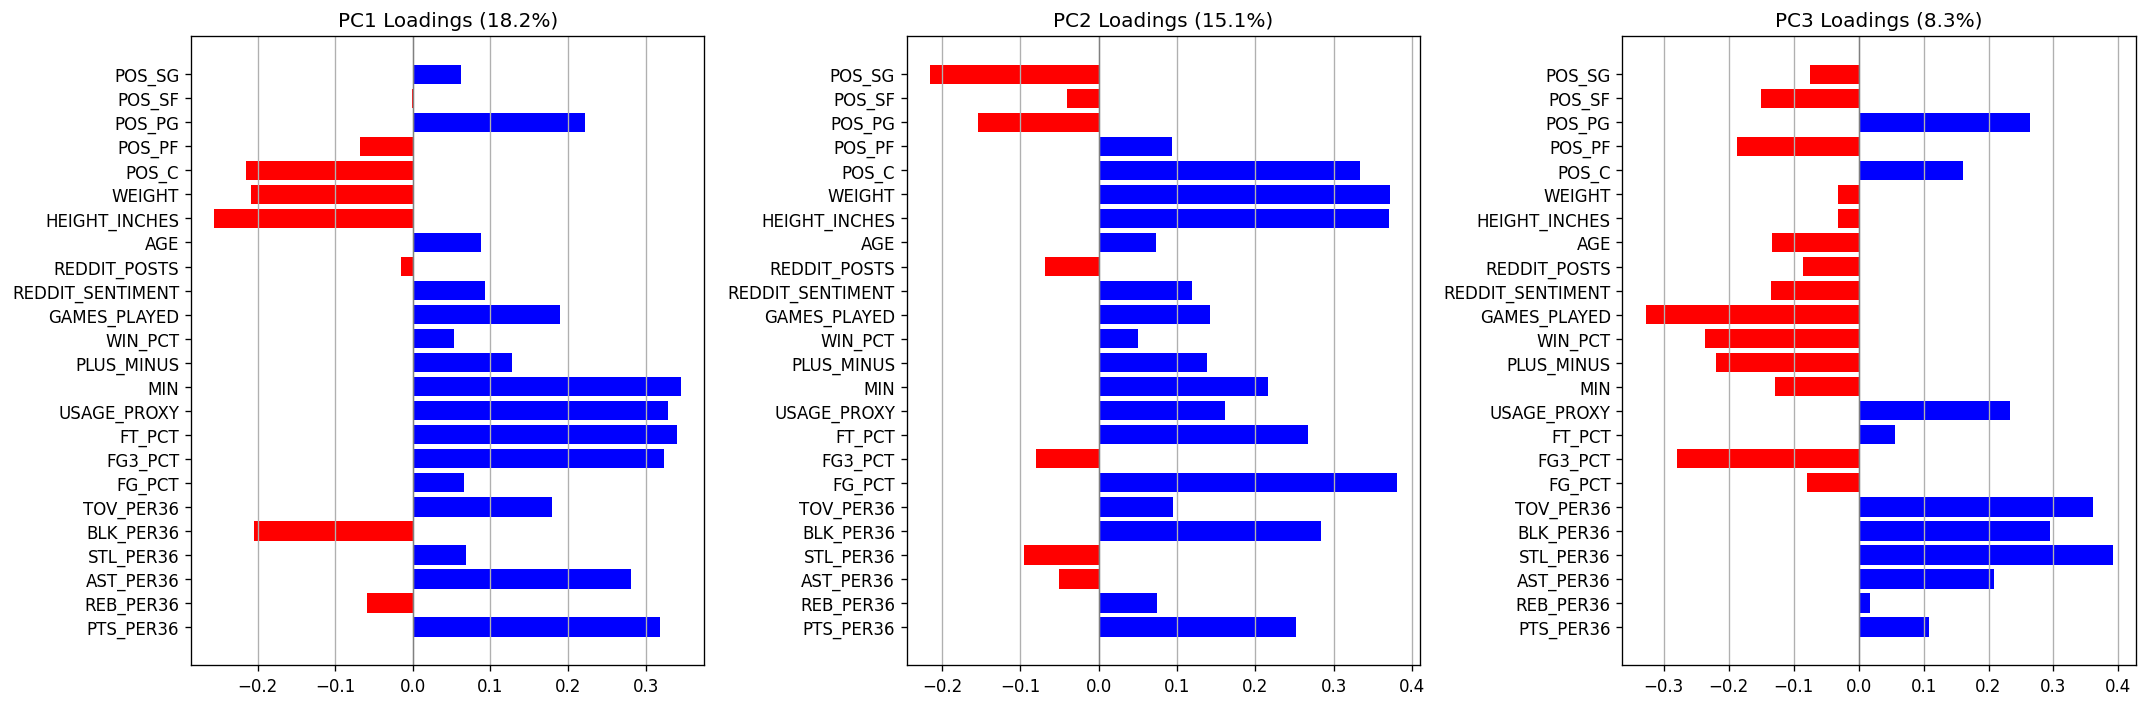

In [29]:
# PCA loadings bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, pc in enumerate(["PC1", "PC2", "PC3"]):
    loadings = pca.components_[i]
    colors = ["red" if v < 0 else "blue" for v in loadings]
    axes[i].barh(ALL_FEATURES, loadings, color=colors)
    axes[i].set_title(f"{pc} Loadings ({pca.explained_variance_ratio_[i]:.1%})")
    axes[i].axvline(0, color="grey", linewidth=0.8)
    axes[i].grid(axis='x')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_pca_loadings.png", bbox_inches="tight")
plt.show()

---
## Section 3: K-Means Clustering — Player Archetypes

Use the elbow method to find optimal K, then cluster players into archetypes.

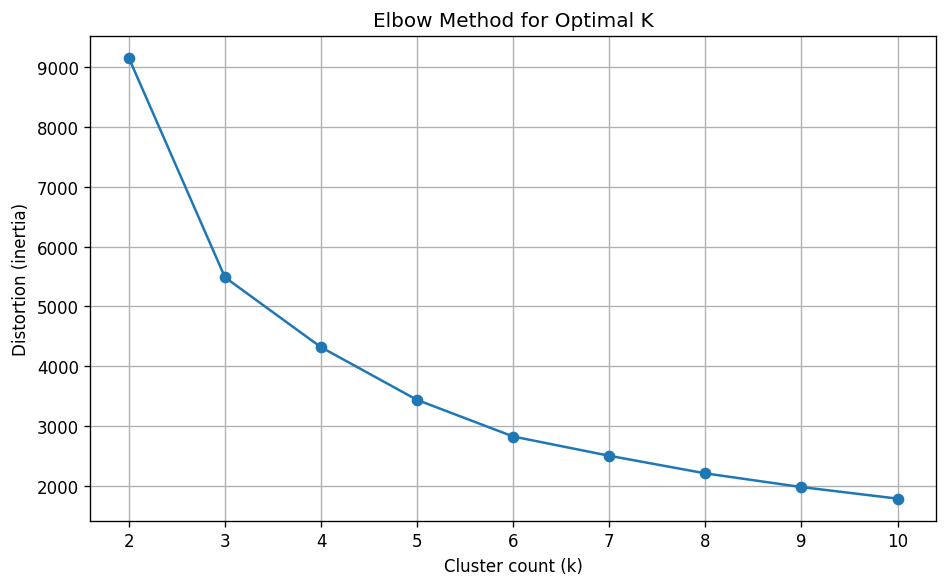

In [30]:
# Elbow method — find optimal k
X_embedded = X_pca[:, :2]  # Use first 2 PCA components for clustering

distortions = []
max_k = 11
for k in range(2, max_k):
    km = KMeans(n_clusters=k, init='random', n_init=10, max_iter=300, random_state=0)
    km.fit(X_embedded)
    distortions.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(2, max_k), distortions, marker='o')
ax.set_xlabel('Cluster count (k)')
ax.set_ylabel('Distortion (inertia)')
ax.set_title('Elbow Method for Optimal K')
ax.grid()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_kmeans_elbow.png")
plt.show()

Inertia: 3435.00


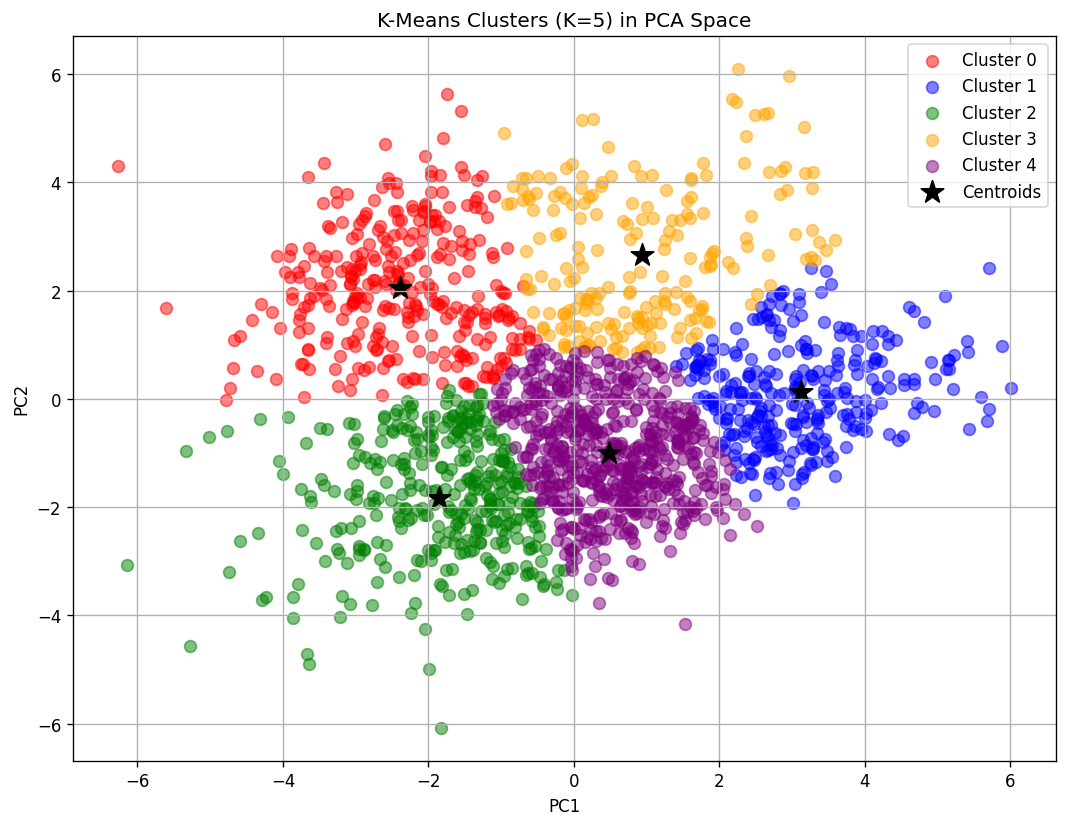

In [31]:
# Fit K-Means with K=5
K = 5
km = KMeans(n_clusters=K, init='random', n_init=10, max_iter=300, random_state=0)
km.fit(X_embedded)

centroids = km.cluster_centers_
labels = km.labels_
print(f"Inertia: {km.inertia_:.2f}")

# Visualize clusters (notebook-5 style: filter arrays per cluster)
fig, ax = plt.subplots(figsize=(9, 7))
cluster_colors = ['red', 'blue', 'green', 'orange', 'purple']

for c in range(K):
    clust_data = np.array([x for i, x in enumerate(X_embedded) if labels[i] == c])
    ax.scatter(clust_data[:, 0], clust_data[:, 1],
               c=cluster_colors[c], marker='o', s=50, alpha=0.5, label=f'Cluster {c}')

# Plot centroids
ax.scatter(centroids[:, 0], centroids[:, 1], marker='*', s=200, c='black', label='Centroids')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'K-Means Clusters (K={K}) in PCA Space')
ax.legend()
ax.grid()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_kmeans_clusters.png")
plt.show()

Cluster Profiles (mean values):
         PTS_PER36  REB_PER36  AST_PER36  STL_PER36  BLK_PER36        MIN  FG_PCT  FG3_PCT  USAGE_PROXY        AGE  REDDIT_SENTIMENT  SEASON_SALARY
CLUSTER                                                                                                                                            
0        13.980000      12.90       2.18       0.98       1.69  18.549999    0.52     0.11         0.38  26.190001             -0.01     6739317.26
1        21.740000       4.95       5.99       1.21       0.42  31.920000    0.45     0.34         0.61  27.219999              0.01    21259750.93
2        10.700000       6.04       2.59       1.16       0.59  13.140000    0.33     0.20         0.34  24.709999             -0.08     2820036.46
3        21.469999       9.04       3.88       1.02       1.03  30.900000    0.51     0.30         0.56  27.139999              0.01    21623296.07
4        14.450000       5.15       3.69       1.23       0.49  23.410000    0.4

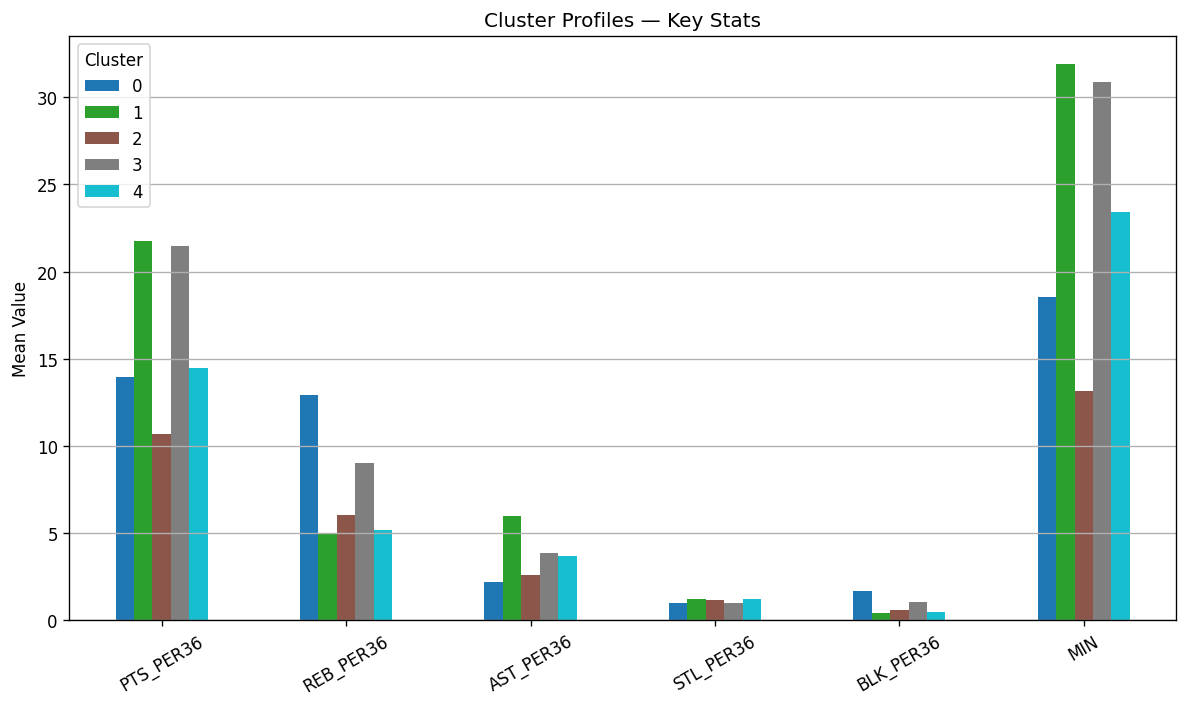

In [32]:
# Cluster profiles
pdf_full["CLUSTER"] = labels

profile_cols = ["PTS_PER36", "REB_PER36", "AST_PER36", "STL_PER36", "BLK_PER36",
                "MIN", "FG_PCT", "FG3_PCT", "USAGE_PROXY", "AGE",
                "REDDIT_SENTIMENT", "SEASON_SALARY"]

cluster_profiles = pdf_full.groupby("CLUSTER")[profile_cols].mean()
print("Cluster Profiles (mean values):")
print(cluster_profiles.round(2).to_string())

print("\nCluster x Position:")
print(pd.crosstab(pdf_full["CLUSTER"], pdf_full["POSITION_SIMPLE"], normalize="index").round(2))

print("\nCluster x Salary Tier:")
print(pd.crosstab(pdf_full["CLUSTER"], pdf_full["SALARY_TIER"], normalize="index").round(2))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 6))
radar_cols = ["PTS_PER36", "REB_PER36", "AST_PER36", "STL_PER36", "BLK_PER36", "MIN"]
cluster_means = pdf_full.groupby("CLUSTER")[radar_cols].mean()
cluster_means.T.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_ylabel("Mean Value")
ax.set_title("Cluster Profiles — Key Stats")
ax.legend(title="Cluster")
ax.grid(axis='y')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_kmeans_profiles.png")
plt.show()

---
## Section 4: Linear Regression — Salary Prediction

Baseline linear regression predicting `LOG_SALARY` from performance, bio, and sentiment features.

In [33]:
# Linear Regression
rgr = LinearRegression()
rgr.fit(X_train_scaled, y_train_reg)

predictions_train = rgr.predict(X_train_scaled)
predictions_test = rgr.predict(X_test_scaled)

train_score = rgr.score(X_train_scaled, y_train_reg)
test_score = rgr.score(X_test_scaled, y_test_reg)

print(f"Intercept: {rgr.intercept_:.4f}")
print(f"\nTrain R^2: {train_score:.4f}")
print(f"Test R^2:  {test_score:.4f}")
print(f"MAE:  {mean_absolute_error(y_test_reg, predictions_test):.4f}")
print(f"MSE:  {mean_squared_error(y_test_reg, predictions_test):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, predictions_test)):.4f}")

Intercept: 15.4605

Train R^2: 0.5791
Test R^2:  0.4178
MAE:  0.7268
MSE:  1.0832
RMSE: 1.0408


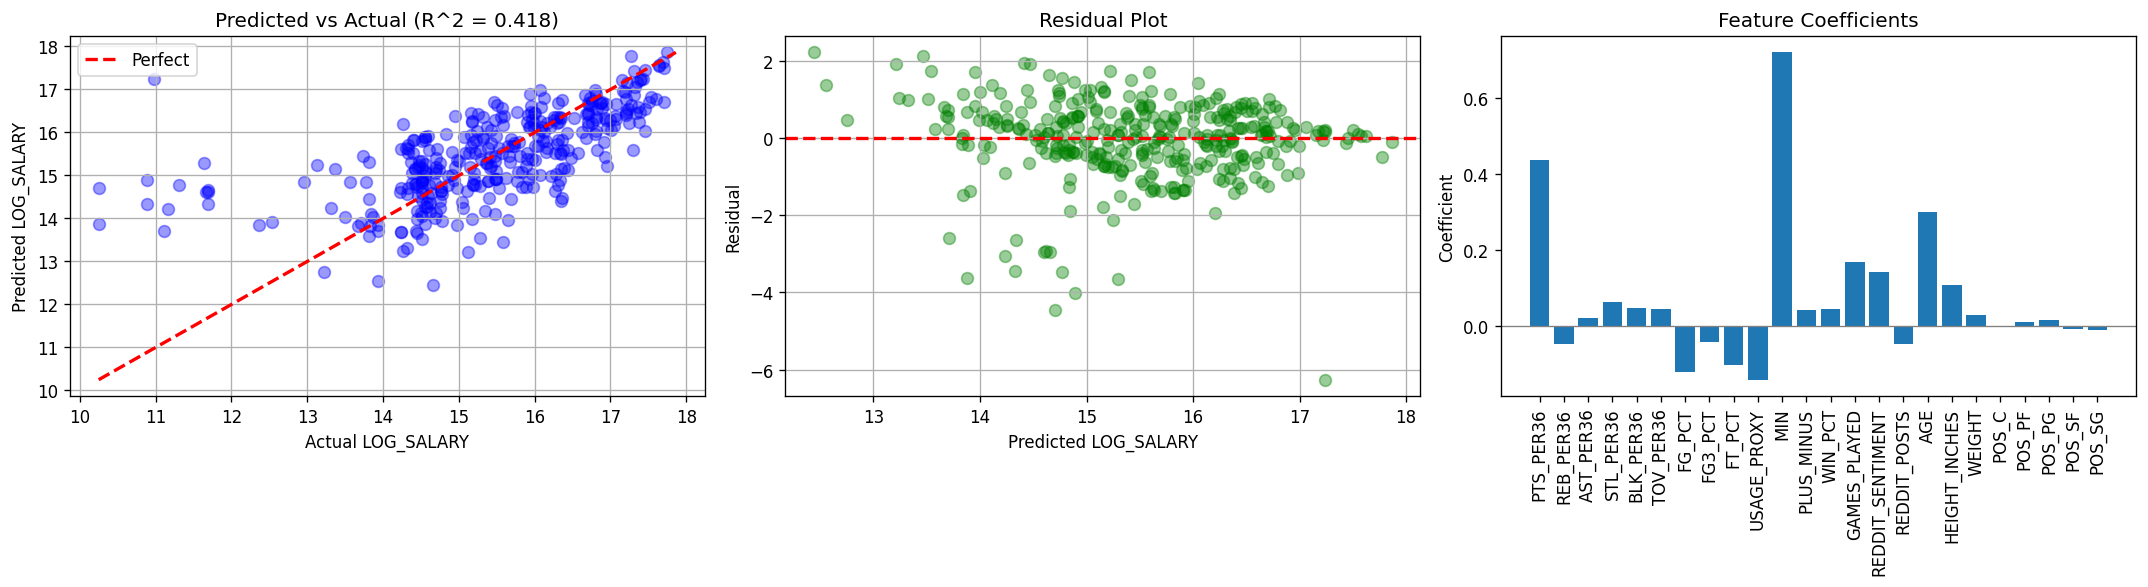

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs Actual scatter
axes[0].scatter(y_test_reg, predictions_test, alpha=0.4, s=50, c='blue', marker='o')
lims = [min(y_test_reg.min(), predictions_test.min()),
        max(y_test_reg.max(), predictions_test.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect')
axes[0].set_xlabel("Actual LOG_SALARY")
axes[0].set_ylabel("Predicted LOG_SALARY")
axes[0].set_title(f"Predicted vs Actual (R^2 = {test_score:.3f})")
axes[0].legend()
axes[0].grid()

# Residual plot
residuals = y_test_reg - predictions_test
axes[1].scatter(predictions_test, residuals, alpha=0.4, s=50, c='green', marker='o')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel("Predicted LOG_SALARY")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot")
axes[1].grid()

# Coefficient bar chart
axes[2].bar(ALL_FEATURES, rgr.coef_)
axes[2].set_ylabel("Coefficient")
axes[2].set_title("Feature Coefficients")
axes[2].axhline(0, color='grey', linewidth=0.8)
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_linreg_results.png", bbox_inches="tight")
plt.show()

---
## Section 5: Regularized Regression — Lasso, Ridge, ElasticNet

Compare L1 (Lasso), L2 (Ridge), and combined (ElasticNet) regularization against the baseline OLS model.

In [35]:
# Lasso (L1)
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train_reg)
lasso_preds = lasso.predict(X_test_scaled)
print(f"Lasso  — R^2: {lasso.score(X_test_scaled, y_test_reg):.4f}  MAE: {mean_absolute_error(y_test_reg, lasso_preds):.4f}  RMSE: {np.sqrt(mean_squared_error(y_test_reg, lasso_preds)):.4f}")

# Ridge (L2)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_reg)
ridge_preds = ridge.predict(X_test_scaled)
print(f"Ridge  — R^2: {ridge.score(X_test_scaled, y_test_reg):.4f}  MAE: {mean_absolute_error(y_test_reg, ridge_preds):.4f}  RMSE: {np.sqrt(mean_squared_error(y_test_reg, ridge_preds)):.4f}")

# ElasticNet (L1 + L2)
enet = ElasticNet(alpha=1.0, l1_ratio=0.5)
enet.fit(X_train_scaled, y_train_reg)
enet_preds = enet.predict(X_test_scaled)
print(f"ENet   — R^2: {enet.score(X_test_scaled, y_test_reg):.4f}  MAE: {mean_absolute_error(y_test_reg, enet_preds):.4f}  RMSE: {np.sqrt(mean_squared_error(y_test_reg, enet_preds)):.4f}")

# Baseline OLS for comparison
print(f"OLS    — R^2: {test_score:.4f}  MAE: {mean_absolute_error(y_test_reg, predictions_test):.4f}  RMSE: {np.sqrt(mean_squared_error(y_test_reg, predictions_test)):.4f}")

Lasso  — R^2: -0.0009  MAE: 1.0447  RMSE: 1.3646
Ridge  — R^2: 0.4184  MAE: 0.7263  RMSE: 1.0402
ENet   — R^2: 0.2171  MAE: 0.8950  RMSE: 1.2069
OLS    — R^2: 0.4178  MAE: 0.7268  RMSE: 1.0408


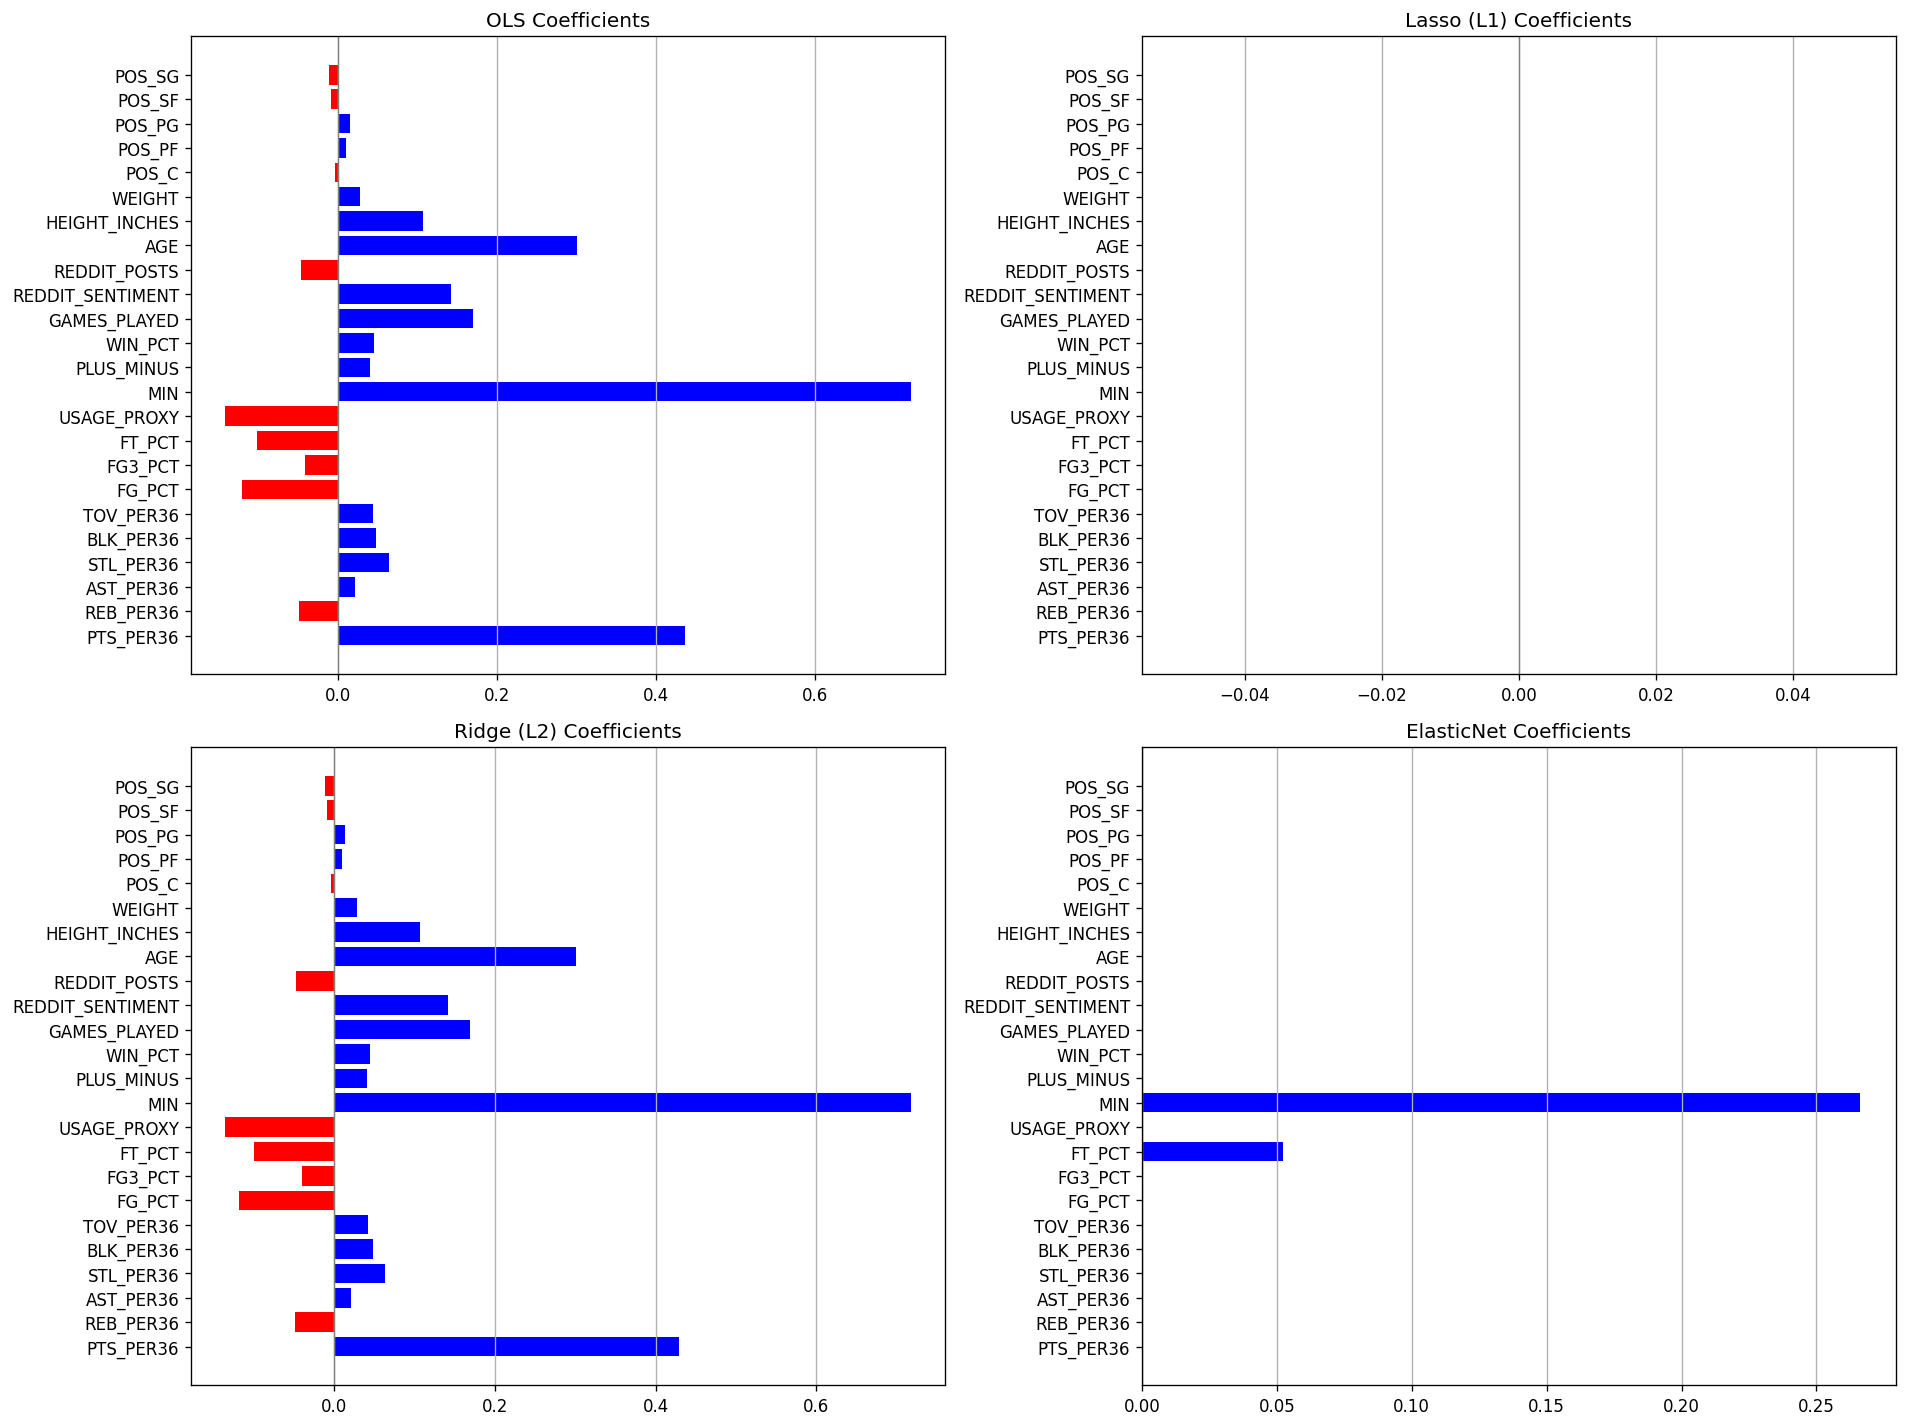

Zero coefficients — Lasso: 24, Ridge: 0, ElasticNet: 22


In [36]:
# Compare coefficients across regularization methods
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models = [("OLS", rgr.coef_), ("Lasso (L1)", lasso.coef_),
          ("Ridge (L2)", ridge.coef_), ("ElasticNet", enet.coef_)]

for ax, (name, coefs) in zip(axes.flatten(), models):
    colors = ["red" if c < 0 else "blue" for c in coefs]
    ax.barh(ALL_FEATURES, coefs, color=colors)
    ax.set_title(f"{name} Coefficients")
    ax.axvline(0, color="grey", linewidth=0.8)
    ax.grid(axis='x')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_regularized_coefs.png", bbox_inches="tight")
plt.show()

# Count zero coefficients (sparsity)
print(f"Zero coefficients — Lasso: {sum(lasso.coef_ == 0)}, Ridge: {sum(ridge.coef_ == 0)}, ElasticNet: {sum(enet.coef_ == 0)}")

---
## Section 6: Decision Tree — Salary Tier Classification

Fit a decision tree classifier for salary tier prediction. Tune `max_depth` by iterating over values and selecting the best.

Default Decision Tree accuracy: 0.5099


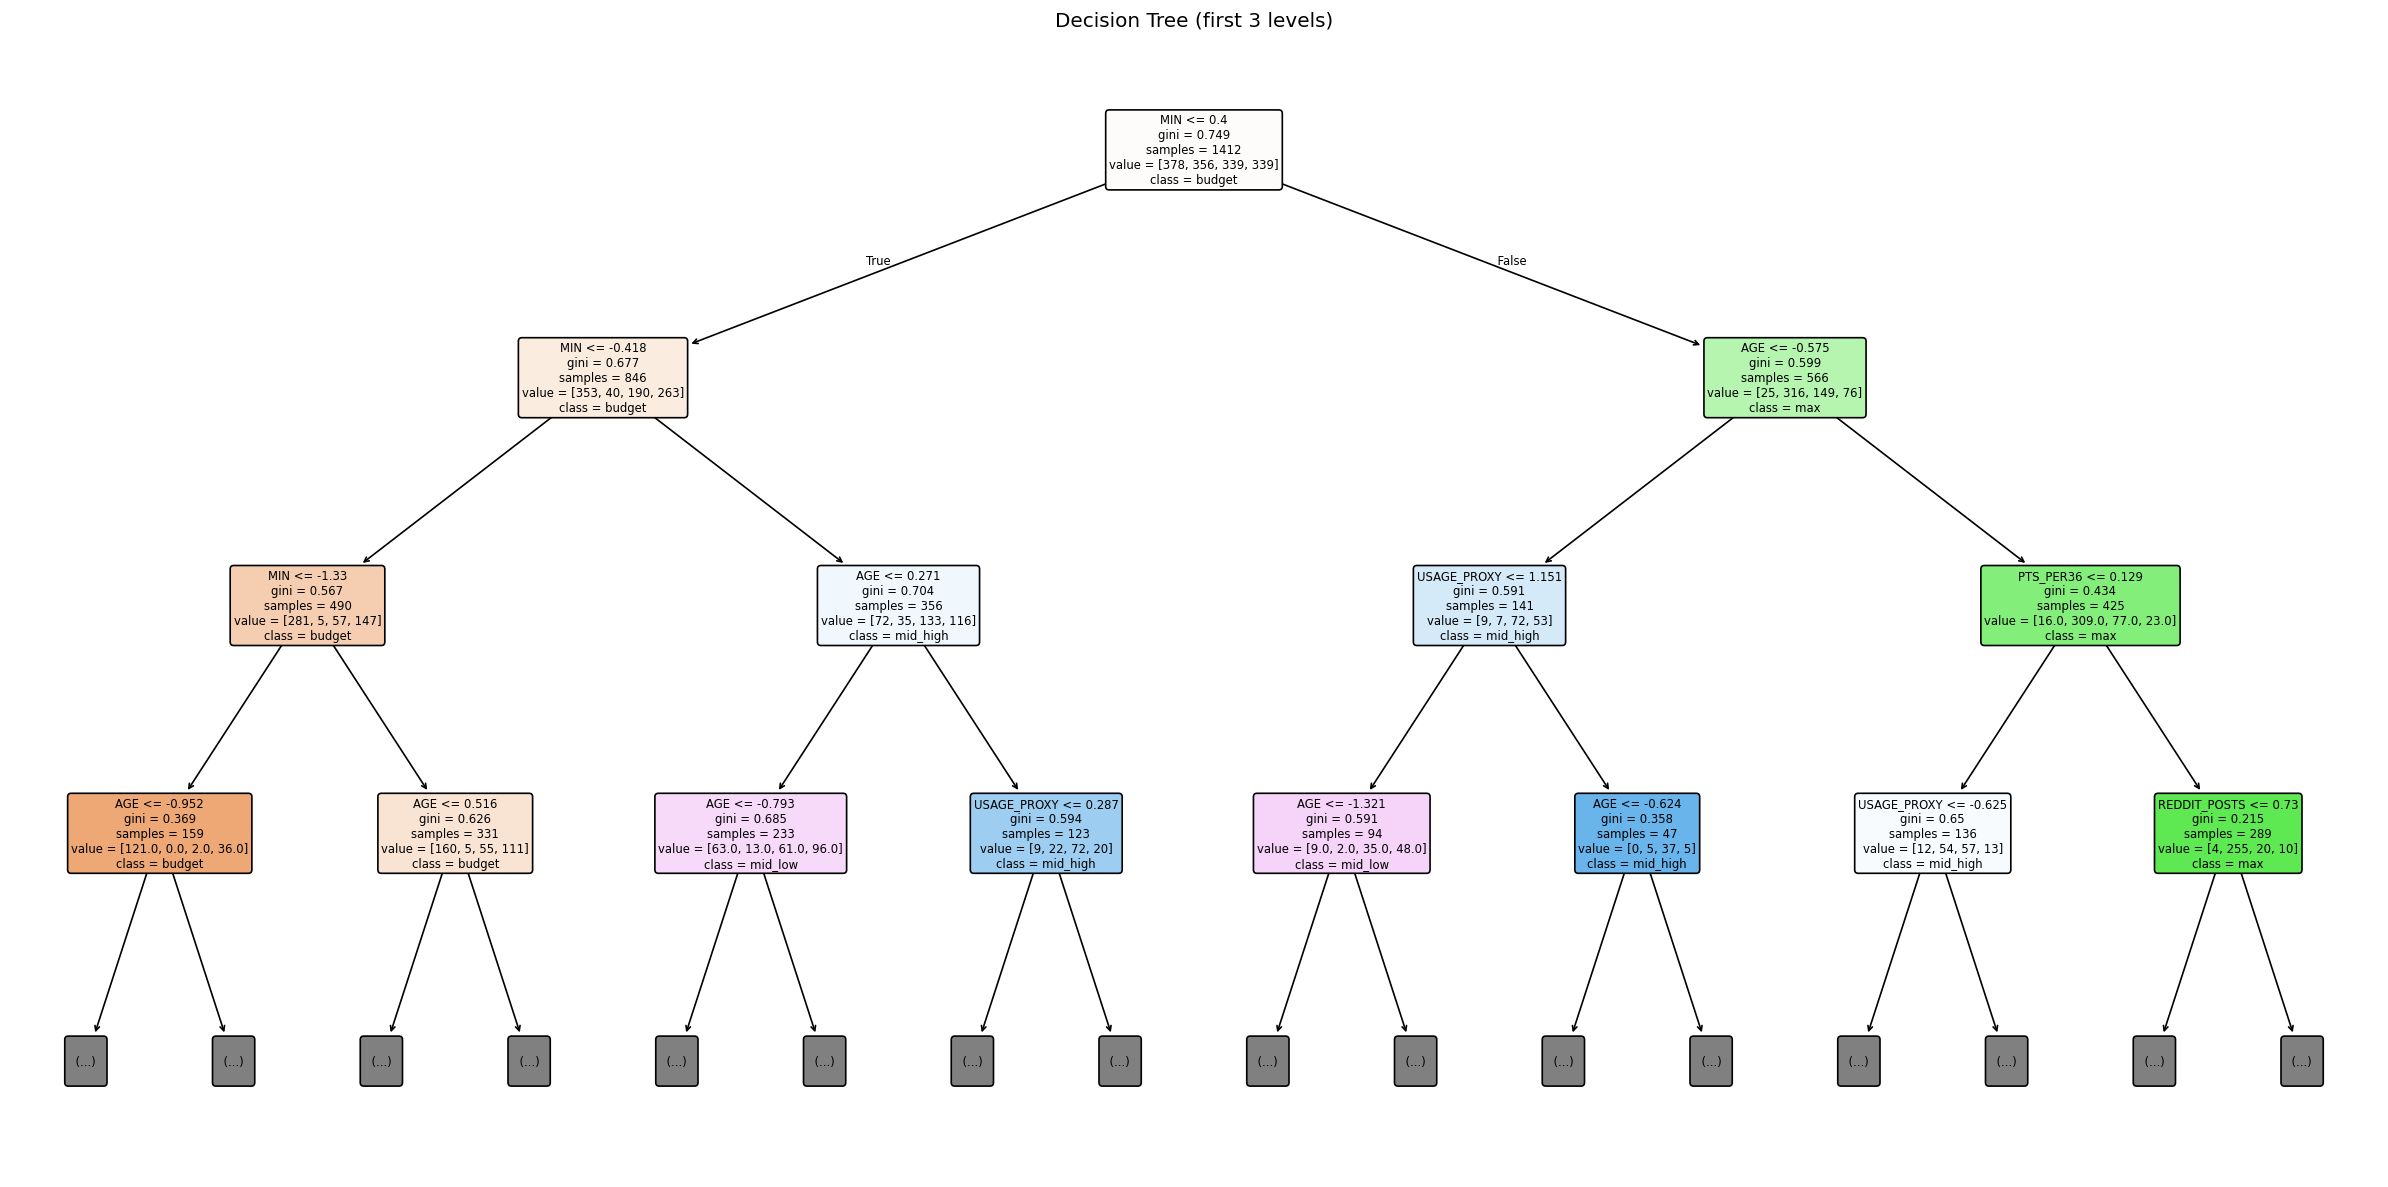

In [37]:
# Decision Tree — default (fully grown)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_scaled, y_train_cls)
default_score = clf.score(X_test_scaled, y_test_cls)
print(f"Default Decision Tree accuracy: {default_score:.4f}")

# Visualize full tree (first 3 levels)
fig, ax = plt.subplots(figsize=(20, 10))
tree.plot_tree(clf, feature_names=ALL_FEATURES, class_names=sorted(np.unique(y_train_cls)),
               filled=True, rounded=True, ax=ax, max_depth=3, fontsize=7)
ax.set_title("Decision Tree (first 3 levels)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_dt_tree.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
# Hyperparameter tuning — find best max_depth (notebook-6 style)
best_score = 0
best_depth = 1

for depth in range(1, 20):
    clf_d = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf_d.fit(X_train_scaled, y_train_cls)
    score = clf_d.score(X_test_scaled, y_test_cls)
    if score > best_score:
        best_score = score
        best_depth = depth

print(f"Best max_depth: {best_depth}, Accuracy: {best_score:.4f}")

# Refit with best depth
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_best.fit(X_train_scaled, y_train_cls)
dt_preds = dt_best.predict(X_test_scaled)

print(f"\nClassification Report:")
print(classification_report(y_test_cls, dt_preds))

Best max_depth: 4, Accuracy: 0.5581

Classification Report:
              precision    recall  f1-score   support

      budget       0.54      0.74      0.62        96
         max       0.72      0.76      0.74        84
    mid_high       0.48      0.38      0.42        92
     mid_low       0.46      0.33      0.39        81

    accuracy                           0.56       353
   macro avg       0.55      0.55      0.54       353
weighted avg       0.55      0.56      0.54       353



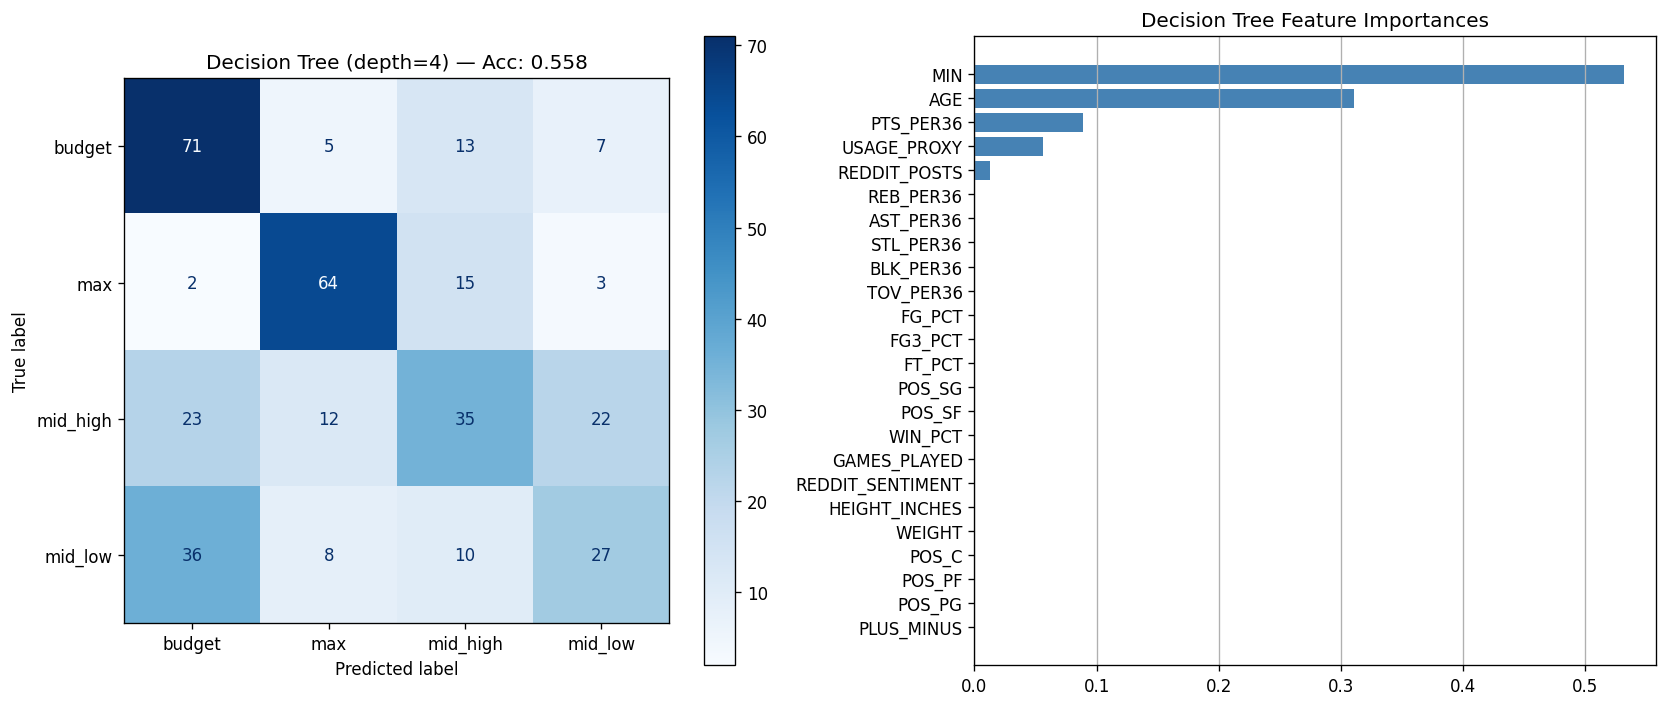

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_cls, dt_preds,
    display_labels=sorted(np.unique(y_cls)),
    cmap="Blues", ax=axes[0],
)
axes[0].set_title(f"Decision Tree (depth={best_depth}) — Acc: {best_score:.3f}")

# Feature importance
importance = pd.DataFrame({
    "Feature": ALL_FEATURES,
    "Importance": dt_best.feature_importances_,
}).sort_values("Importance", ascending=True)

axes[1].barh(importance["Feature"], importance["Importance"], color="steelblue")
axes[1].set_title("Decision Tree Feature Importances")
axes[1].grid(axis='x')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_dt_results.png", bbox_inches="tight")
plt.show()

---
## Section 7: Logistic Regression — Salary Tier Classification (Pipeline)

Logistic regression classifier using a Pipeline (Scaler + PCA + LogReg)

Logistic Regression Pipeline Accuracy: 0.5694

Classification Report:
              precision    recall  f1-score   support

      budget       0.61      0.62      0.62        96
         max       0.69      0.81      0.75        84
    mid_high       0.48      0.38      0.42        92
     mid_low       0.46      0.47      0.46        81

    accuracy                           0.57       353
   macro avg       0.56      0.57      0.56       353
weighted avg       0.56      0.57      0.56       353



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


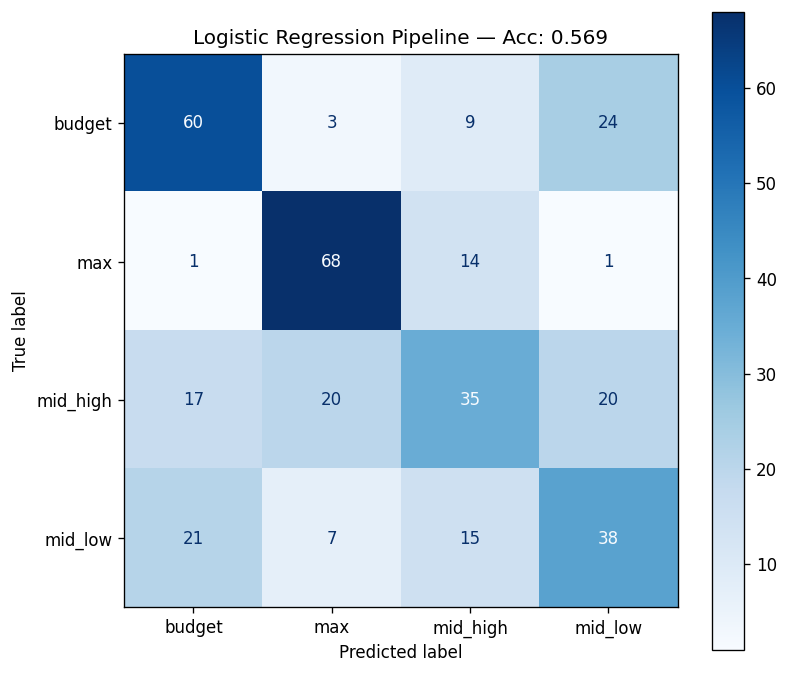

In [40]:
# Pipeline: StandardScaler -> PCA -> LogisticRegression
pipe = Pipeline(steps=[
    ('Scale', StandardScaler()),
    ('PCA', PCA()),
    ('LogReg', LogisticRegression(max_iter=10000, penalty='l2')),
])

pipe.fit(X_train, y_train_cls)
logreg_preds = pipe.predict(X_test)

logreg_acc = accuracy_score(y_test_cls, logreg_preds)
print(f"Logistic Regression Pipeline Accuracy: {logreg_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_cls, logreg_preds))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_cls, logreg_preds,
    display_labels=sorted(np.unique(y_cls)),
    cmap="Blues", ax=ax,
)
ax.set_title(f"Logistic Regression Pipeline — Acc: {logreg_acc:.3f}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_logreg_results.png")
plt.show()

---
## Section 8: Random Forest — Ensemble Classification

Random Forest aggregates many decision trees to improve accuracy and reduce overfitting.

In [41]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train_cls)

rf_preds = rf.predict(X_test_scaled)
rf_acc = rf.score(X_test_scaled, y_test_cls)

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_cls, rf_preds))

Random Forest Accuracy: 0.6204

Classification Report:
              precision    recall  f1-score   support

      budget       0.59      0.69      0.64        96
         max       0.79      0.81      0.80        84
    mid_high       0.55      0.55      0.55        92
     mid_low       0.54      0.42      0.47        81

    accuracy                           0.62       353
   macro avg       0.62      0.62      0.62       353
weighted avg       0.62      0.62      0.62       353



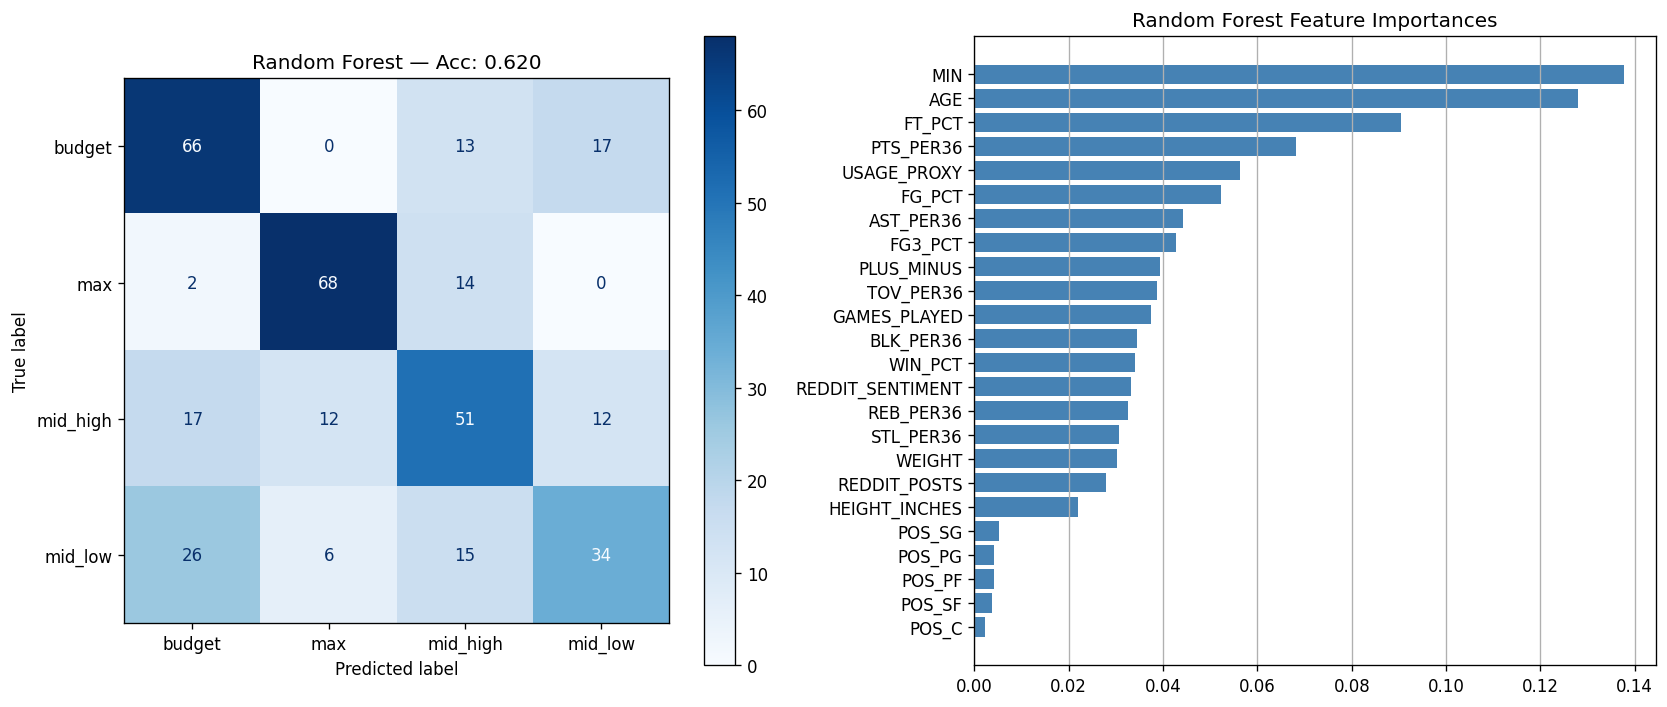

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test_cls, rf_preds,
    display_labels=sorted(np.unique(y_cls)),
    cmap="Blues", ax=axes[0],
)
axes[0].set_title(f"Random Forest — Acc: {rf_acc:.3f}")

# Feature importance
rf_imp = pd.DataFrame({
    "Feature": ALL_FEATURES,
    "Importance": rf.feature_importances_,
}).sort_values("Importance", ascending=True)

axes[1].barh(rf_imp["Feature"], rf_imp["Importance"], color="steelblue")
axes[1].set_title("Random Forest Feature Importances")
axes[1].grid(axis='x')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_rf_results.png", bbox_inches="tight")
plt.show()

---
## Section 9: Model Comparison

MODEL COMPARISON

--- Regression (target: LOG_SALARY) ---
Model                     R^2      MAE     RMSE
OLS                    0.4178   0.7268   1.0408
Lasso                 -0.0009   1.0447   1.3646
Ridge                  0.4184   0.7263   1.0402
ElasticNet             0.2171   0.8950   1.2069

--- Classification (target: SALARY_TIER) ---
Model                  Accuracy
Decision Tree            0.5581
Logistic Reg             0.5694
Random Forest            0.6204


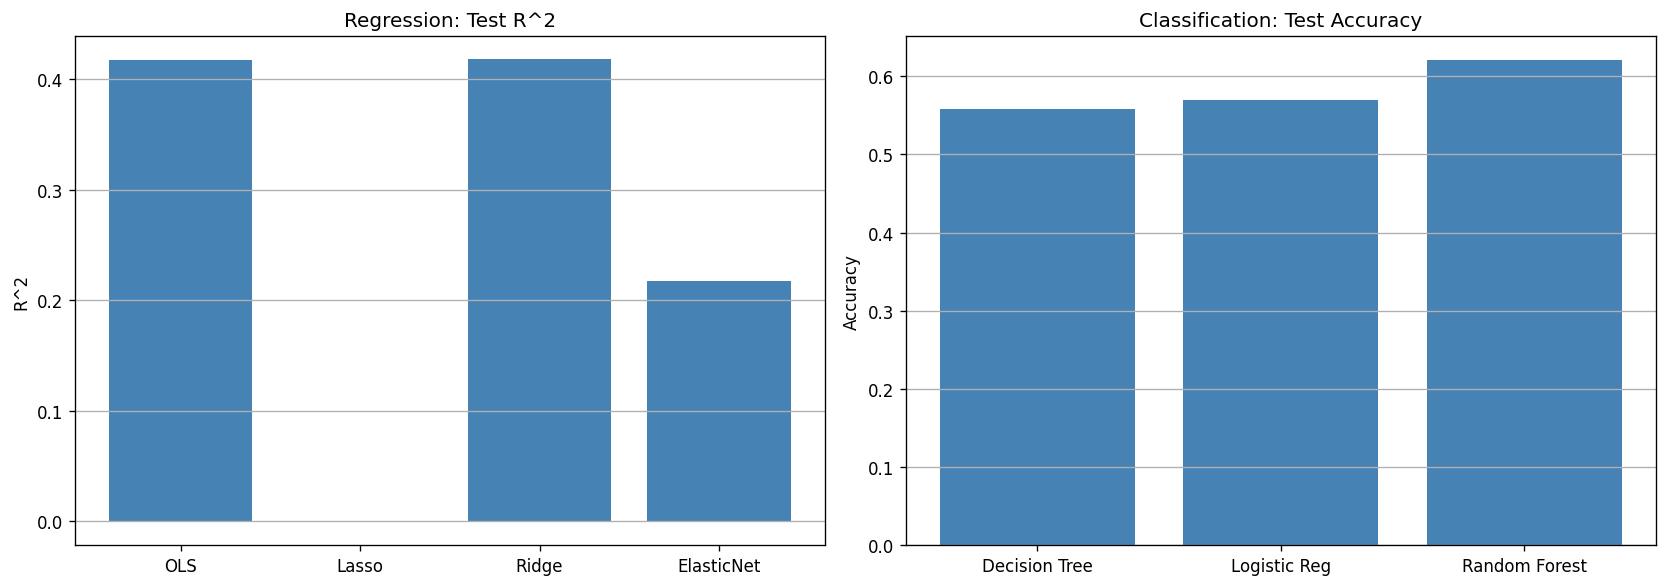

In [43]:
print("=" * 75)
print("MODEL COMPARISON")
print("=" * 75)

print("\n--- Regression (target: LOG_SALARY) ---")
print(f"{'Model':<20s} {'R^2':>8s} {'MAE':>8s} {'RMSE':>8s}")
for name, model in [("OLS", rgr), ("Lasso", lasso), ("Ridge", ridge), ("ElasticNet", enet)]:
    preds = model.predict(X_test_scaled)
    print(f"{name:<20s} {model.score(X_test_scaled, y_test_reg):>8.4f} "
          f"{mean_absolute_error(y_test_reg, preds):>8.4f} "
          f"{np.sqrt(mean_squared_error(y_test_reg, preds)):>8.4f}")

print("\n--- Classification (target: SALARY_TIER) ---")
print(f"{'Model':<20s} {'Accuracy':>10s}")
print(f"{'Decision Tree':<20s} {best_score:>10.4f}")
print(f"{'Logistic Reg':<20s} {logreg_acc:>10.4f}")
print(f"{'Random Forest':<20s} {rf_acc:>10.4f}")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression R^2
reg_names = ["OLS", "Lasso", "Ridge", "ElasticNet"]
reg_r2 = [rgr.score(X_test_scaled, y_test_reg), lasso.score(X_test_scaled, y_test_reg),
           ridge.score(X_test_scaled, y_test_reg), enet.score(X_test_scaled, y_test_reg)]
axes[0].bar(reg_names, reg_r2, color='steelblue')
axes[0].set_ylabel("R^2")
axes[0].set_title("Regression: Test R^2")
axes[0].grid(axis='y')

# Classification accuracy
cls_names = ["Decision Tree", "Logistic Reg", "Random Forest"]
cls_acc = [best_score, logreg_acc, rf_acc]
axes[1].bar(cls_names, cls_acc, color='steelblue')
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Classification: Test Accuracy")
axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_model_comparison.png", bbox_inches="tight")
plt.show()

---
## Section 10: Reddit Sentiment Feature Impact

Compare models with and without the Reddit sentiment features to measure their contribution.

=== Reddit Sentiment Impact ===
Metric                     With Reddit      Without      Delta
OLS R^2                         0.4178       0.4323    -0.0145
RF Accuracy                     0.6204       0.6176    +0.0028


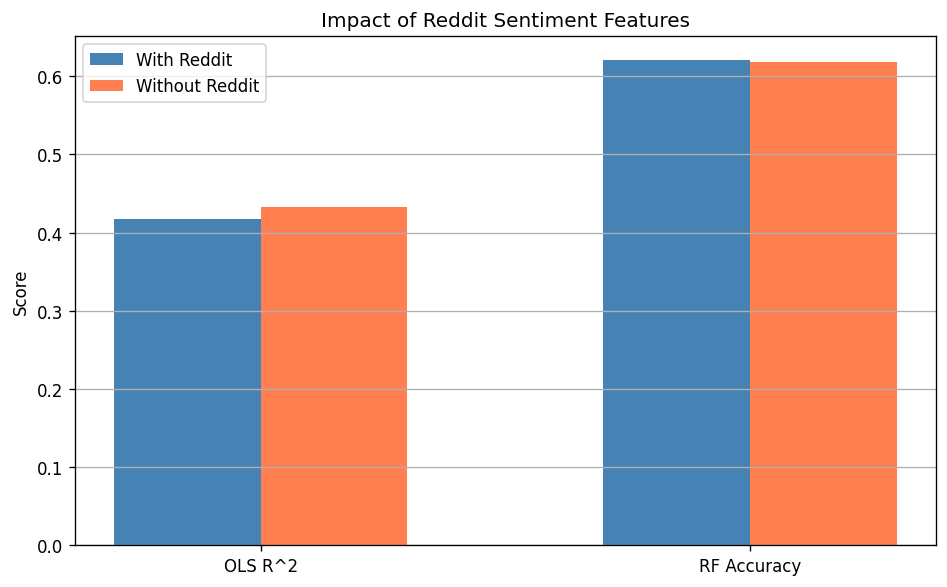

In [44]:
# Features without Reddit
FEATURES_NO_REDDIT = [f for f in ALL_FEATURES if f not in ("REDDIT_SENTIMENT", "REDDIT_POSTS")]
idx_no_reddit = [ALL_FEATURES.index(f) for f in FEATURES_NO_REDDIT]

X_train_nr = X_train_scaled[:, idx_no_reddit]
X_test_nr = X_test_scaled[:, idx_no_reddit]

# OLS without Reddit
rgr_nr = LinearRegression()
rgr_nr.fit(X_train_nr, y_train_reg)
r2_nr = rgr_nr.score(X_test_nr, y_test_reg)

# Random Forest without Reddit
rf_nr = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_nr.fit(X_train_nr, y_train_cls)
acc_nr = rf_nr.score(X_test_nr, y_test_cls)

print("=== Reddit Sentiment Impact ===")
print(f"{'Metric':<25s} {'With Reddit':>12s} {'Without':>12s} {'Delta':>10s}")
print(f"{'OLS R^2':<25s} {test_score:>12.4f} {r2_nr:>12.4f} {test_score - r2_nr:>+10.4f}")
print(f"{'RF Accuracy':<25s} {rf_acc:>12.4f} {acc_nr:>12.4f} {rf_acc - acc_nr:>+10.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
ax.bar(x - 0.15, [test_score, rf_acc], 0.3, label="With Reddit", color="steelblue")
ax.bar(x + 0.15, [r2_nr, acc_nr], 0.3, label="Without Reddit", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(["OLS R^2", "RF Accuracy"])
ax.set_ylabel("Score")
ax.set_title("Impact of Reddit Sentiment Features")
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_reddit_impact.png")
plt.show()